In [9]:
import zipfile
import os

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [11]:
#combining the different CSV files for different emojis
dataset = "data/"
data_list = []

#looping through each file
for file in os.listdir(dataset):
    # only the csv files
    if file.endswith(".csv"):
        #remove the ".csv"
        label = file[:-4]
        df = pd.read_csv(
            os.path.join(dataset, file),
            engine="python",
            #skipping
            encoding_errors="ignore",
            encoding="utf-8",
            #naming 'text' column
            names=["text"],
        )
        # adding new columns
        df["emoji_label"] = label
        data_list.append(df)

# finally combining all the filext
data = pd.concat(data_list)


In [12]:
print("Number of rows in our dataset:", len(data))
print("Number of unique emoji labels:", data['emoji_label'].nunique())
print("Most common emojis:\n", data['emoji_label'].value_counts().head(10))

#adding text length metric to the data
data['text_length'] = data['text'].astype(str).apply(len)

Number of rows in our dataset: 860071
Number of unique emoji labels: 43
Most common emojis:
 emoji_label
backhand_index_pointing_right    20026
egg                              20002
red_heart                        20002
partying_face                    20002
face_savoring_food               20001
thinking_face                    20001
smiling_face_with_sunglasses     20001
hatching_chick                   20001
hot_face                         20001
white_heart                      20001
Name: count, dtype: int64


In [13]:
print("Avg text length:", round(data['text_length'].mean(), 2))
print("Min text length:", data['text_length'].min())
print("Max text length:", data['text_length'].max())

Avg text length: 107.31
Min text length: 3
Max text length: 971


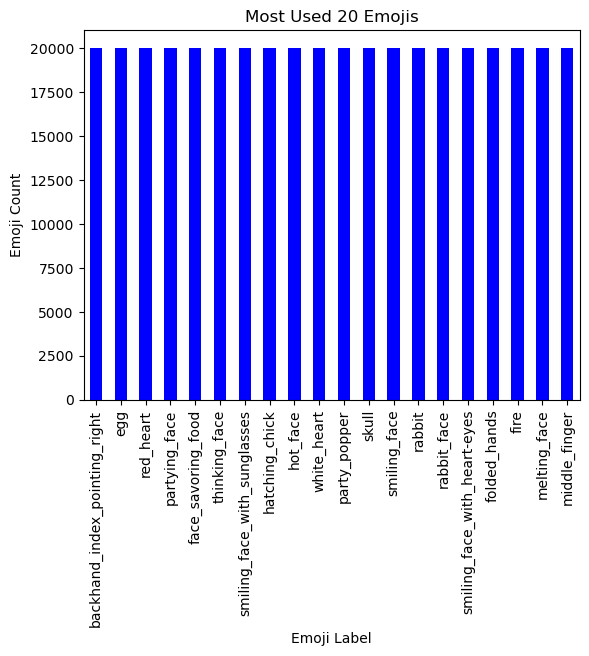

In [14]:
plt.figure()
data['emoji_label'].value_counts().head(20).plot(kind='bar', color='blue')
plt.title("Most Used 20 Emojis")
plt.ylabel("Emoji Count")
plt.xlabel("Emoji Label")
plt.show()

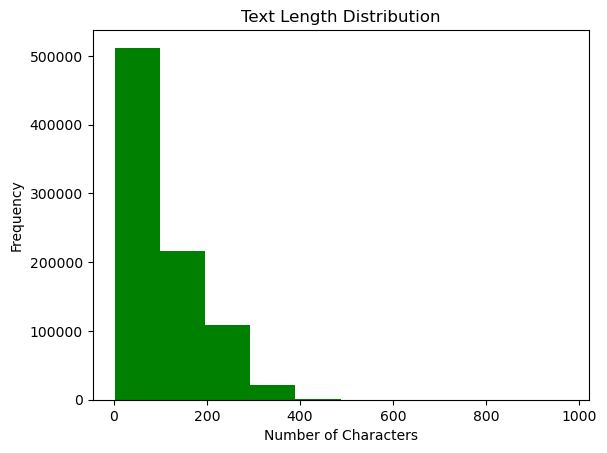

In [15]:
plt.figure()
plt.hist(data['text_length'], color='green')
plt.title("Text Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.show()

In [16]:
print("Summary:")
print("The dataset has", len(data), "text datapoints with", data['emoji_label'].nunique(), "unique emoji labels.")
print("Most frequent emojis:", list(data['emoji_label'].value_counts().head(5).index))

Summary:
The dataset has 860071 text datapoints with 43 unique emoji labels.
Most frequent emojis: ['backhand_index_pointing_right', 'egg', 'red_heart', 'partying_face', 'face_savoring_food']
